In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from keras.datasets import mnist
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
import random
np.random.seed(0)

In [ ]:
#%pip install kagglehub


Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ------------------

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hojjatk/mnist-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\mishr\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1


In [5]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [6]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


In [7]:
x_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [8]:
set(y_train)

{np.uint8(0),
 np.uint8(1),
 np.uint8(2),
 np.uint8(3),
 np.uint8(4),
 np.uint8(5),
 np.uint8(6),
 np.uint8(7),
 np.uint8(8),
 np.uint8(9)}

<function matplotlib.pyplot.show(close=None, block=None)>

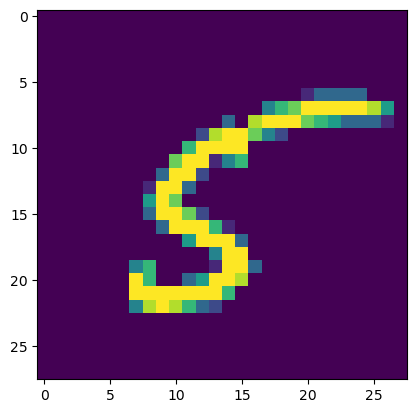

In [9]:
plt.imshow(x_train[y_train==5][50])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

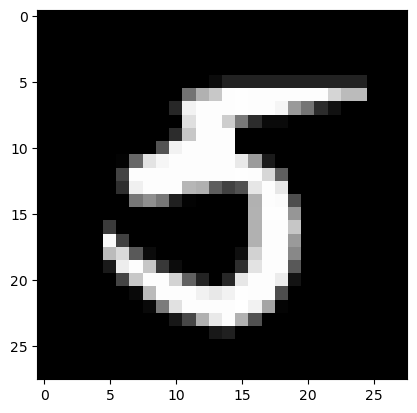

In [10]:
plt.imshow(x_train[y_train==5][500],cmap='gray')
plt.show

In [11]:
for i in range(0,10):
    print(i,':',len(x_train[y_train==i]))

0 : 5923
1 : 6742
2 : 5958
3 : 6131
4 : 5842
5 : 5421
6 : 5918
7 : 6265
8 : 5851
9 : 5949


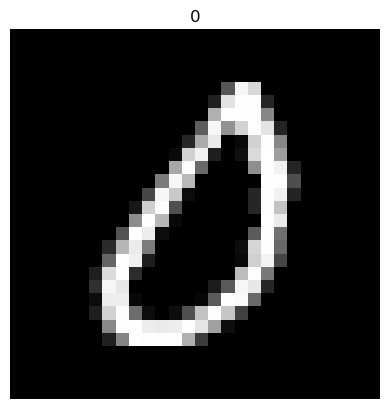

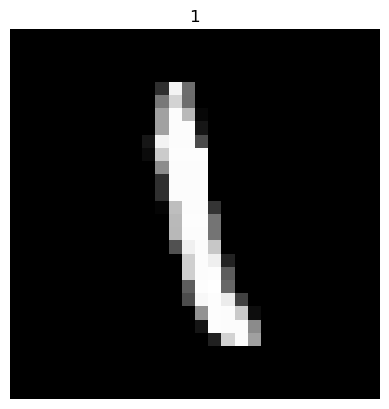

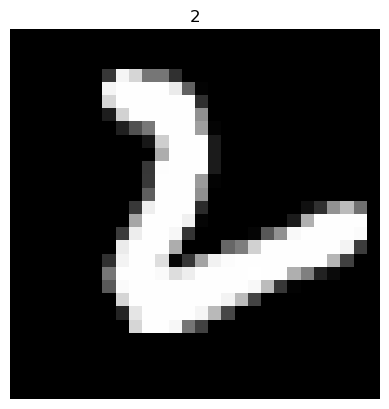

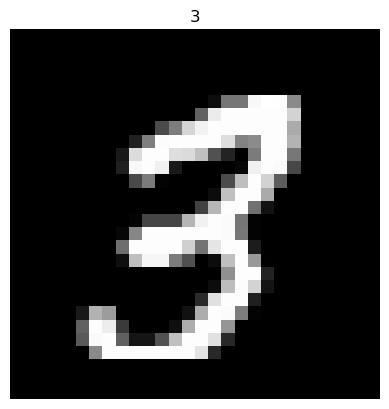

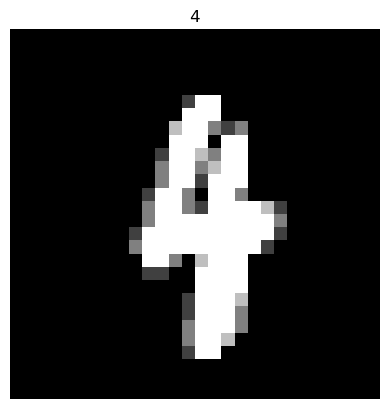

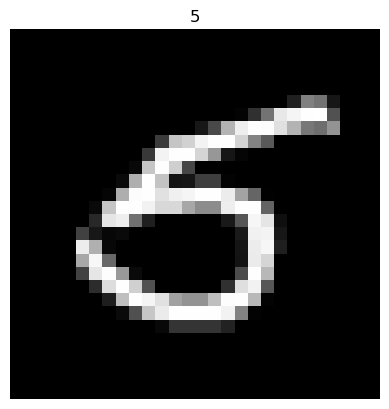

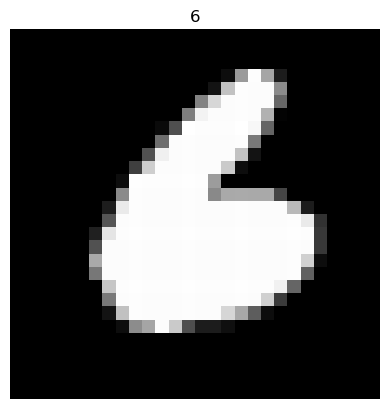

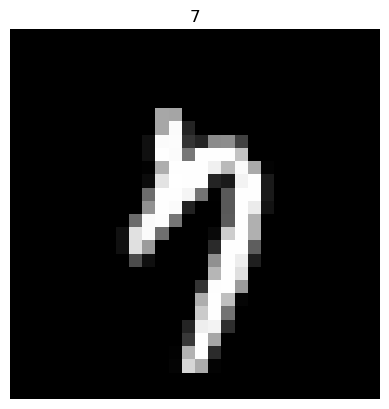

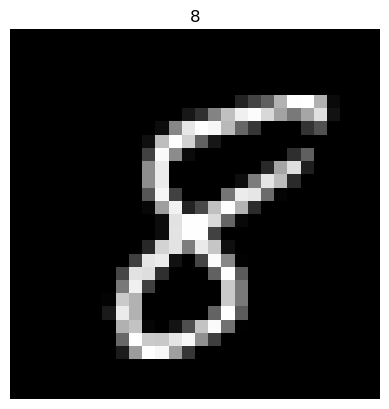

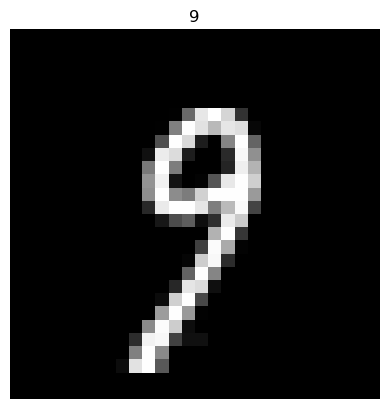

In [12]:
for i in range(0,10):
    plt.imshow(x_train[y_train==i][np.random.randint(0,5000)],cmap='gray')
    plt.title(str(i))
    plt.axis('off')
    plt.show()

In [13]:
from keras.utils import to_categorical

In [14]:
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test)


In [15]:
x_train=x_train/255
x_test=x_test/255

In [16]:
x_train

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [18]:
x_train=x_train.reshape(60000,784)
x_test=x_test.reshape(10000,784)

In [17]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(60000, 10))

In [21]:
# Model training 
model = Sequential()
# Input layer 
model.add(Dense(35,input_dim=784,activation="relu"))  
# Hidden layer 
model.add(Dense(15, activation="relu"))              
model.add(Dense(25, activation="relu"))          
#Output Layer    
model.add(Dense(10, activation="softmax"))               
model.compile(Adam(learning_rate=0.01),loss="categorical_crossentropy",metrics=['accuracy'])

In [22]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 35)             │        27,475 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │           540 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 25)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,675 (112.01 KB)

 Trainable params: 28,675 (112.01 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
h=model.fit(x_train,y_train,validation_split=0.1,epochs=10)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9662 - loss: 0.1362 - val_accuracy: 0.9610 - val_loss: 0.1484
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9664 - loss: 0.1338 - val_accuracy: 0.9633 - val_loss: 0.1669
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9679 - loss: 0.1258 - val_accuracy: 0.9632 - val_loss: 0.1580
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9694 - loss: 0.1248 - val_accuracy: 0.9657 - val_loss: 0.1406
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9679 - loss: 0.1269 - val_accuracy: 0.9603 - val_loss: 0.1771
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9704 - loss: 0.1220 - val_accuracy: 0.9657 - val_loss: 0.1395
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9695 - loss: 0.1252 - val_accuracy: 0.9680 - val_loss: 0.1467
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9704 - loss: 

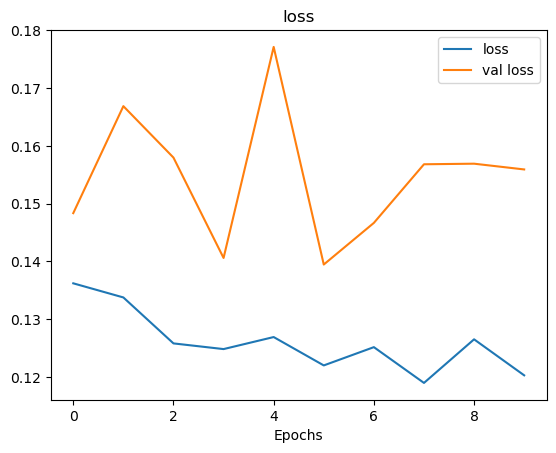

In [28]:
plt.plot(h.history['loss'])
plt.plot(h.history["val_loss"])
plt.legend(['loss','val loss'])
plt.title('loss')
plt.xlabel('Epochs')
plt.show()

In [29]:
import cv2
import matplotlib.pyplot as plt

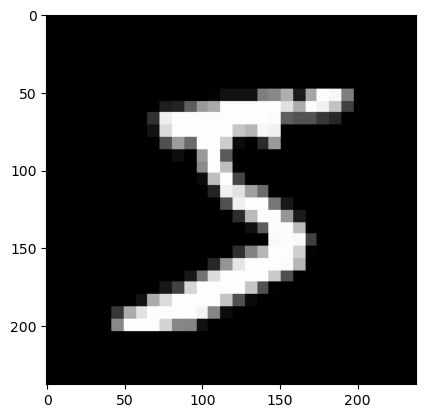

In [32]:
img=cv2.imread(r"C:\Users\mishr\Downloads\MNIST_6_0.webp")
plt.imshow(img,cmap='gray')
plt.show()

In [33]:
img.shape

(238, 238, 3)

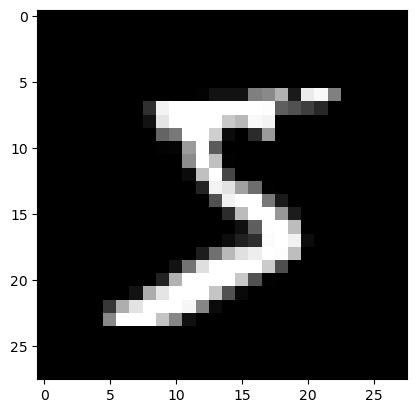

In [34]:
img=cv2.resize(img,(28,28))
img=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
plt.imshow(img,cmap='gray')
plt.show()

In [36]:
img=img/255
img=img.reshape(1,784)

In [37]:
pred=model.predict(img)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


array([[0.07811808, 0.02123832, 0.33108643, 0.15826799, 0.02639152,
        0.13997836, 0.02276944, 0.05424618, 0.10363156, 0.06427218]],
      dtype=float32)

In [38]:
pred=np.argmax(pred,axis=1)
pred

array([2])